In [53]:
!pip install pandas
!pip install openpyxl
!pip install lightgbm
!pip install scikit-learn

In [3]:
import pandas as pd

In [6]:
data = pd.read_excel("data_raw/DataSet_V49 (2).xlsx")

In [15]:
data.head(1)

,Код пациента,Name,Age,Sex,Наличие в БД,Наличие в файле,STEMI,ЧКВ,Дата STEMI,Вид STEMI,...,BEVenMax,HCO3VenMin (b),HCO3VenMin (a),HCO3VenMin,HCO3VenMax (b),HCO3VenMax (a),HCO3VenMax,BNP (b),BNP (a),BNP
0,20-6545,Хасьянов РА,78.0,М,Да,Да,Нет,Да,NaN,NaN,...,-5.0,18.5,18.5,18.5,18.5,18.5,18.5,NaN,NaN,NaN


In [34]:
(len(data["Смерть"]) - len(data[data["Смерть"] == "Да"]) - len(data[data["Смерть"] == "Нет"])) / len(data["Смерть"]) * 100 

4.687320711417097

In [51]:
#len(data[data["Смерть"] == "Да"]) 
len(data[data["STEMI"] == "Нет"])

10791

In [28]:
data[data["Смерть"] != "nan"]

,Код пациента,Name,Age,Sex,Наличие в БД,Наличие в файле,STEMI,ЧКВ,Дата STEMI,Вид STEMI,...,BEVenMax,HCO3VenMin (b),HCO3VenMin (a),HCO3VenMin,HCO3VenMax (b),HCO3VenMax (a),HCO3VenMax,BNP (b),BNP (a),BNP
0,20-6545,Хасьянов РА,78.0,М,Да,Да,Нет,Да,NaN,NaN,...,-5.0,18.5,18.5,18.5,18.5,18.5,18.5,NaN,NaN,NaN
1,19-22109,Тюркова ГГ,80.0,Ж,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17-13439,Ремизов РВ,40.0,М,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,16-20326,Синенко ОП,78.0,М,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9993,Комолов ВИ,75.0,М,Да,Да,Да,Да,2015-07-09 00:00:00,Передний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17425,10019,Гаевский АИ,60.0,М,Да,Да,Да,Да,2021-06-08 00:00:00,Передний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17426,10,Сальникова ВС,81.0,Ж,Да,Да,Да,Да,2020-12-31 00:00:00,Передний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17427,1,Халиман ОА,48.0,М,Да,Да,Да,Да,2020-01-01 00:00:00,Передний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17428,2024-06-18 00:00:00,Журавлев АЮ,50.0,М,Да,Да,Да,Да,2018-01-01 00:00:00,Задний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
data = data.dropna(subset=['Смерть'])
data = data.drop(['Дата STEMI', 'Дата направления (Общий анализ крови)', 'Дата взятия биоматериала (Общий анализ крови)', 'Дата выполнения (Общий анализ крови)', 'Дата направления (Общий анализ крови-экспрес)', 'Дата взятия биоматериала (Общий анализ крови-экспрес)', 'Дата выполнения (Общий анализ крови-экспрес)', 'Начало операции(ИБ)(Новый)', 'Конец операции(ИБ)(Новый)', 'дата поступления', 'дата выписки', 'Поступление в реанимацию', 'Выписка из реанимации', 'Дата и время развития SOFA 8 и более', 'Время введения первого антибиотика'], axis=1)

In [79]:
def clean_column_names(df):
    df = df.copy()
    df.columns = [re.sub(r'[^0-9a-zA-Z_]', '_', str(col)) for col in df.columns]
    return df

In [102]:
x = data.drop(['Смерть'], axis=1)
y = data['Смерть']

In [84]:
x.dtypes

Код пациента       object
Name               object
Age               float64
Sex                object
Наличие в БД       object
                   ...   
HCO3VenMax (a)    float64
HCO3VenMax        float64
BNP (b)           float64
BNP (a)           float64
BNP               float64
Length: 449, dtype: object

In [103]:
x = x.select_dtypes(include=[np.number])

In [82]:
for col in x.columns:
    if x[col].dtype == 'object':
        x[col] = x[col].astype('category')

AttributeError: 'DataFrame' object has no attribute 'dtype'

In [61]:
categorical_cols = x.select_dtypes(include=["object", "category"]).columns
for col in categorical_cols:
    x[col] = x[col].astype("category")

In [24]:
from sklearn.model_selection import train_test_split


In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [72]:
for col in X_train.select_dtypes(include=['datetime64[ns]']).columns:
    x[col] = x[col].astype('int64') // 10 ** 9
    X_train[col] = X_train[col].astype('int64') // 10**9  # переводим в секунды
    X_test[col] = X_test[col].astype('int64') // 10**9


In [105]:
import re

def clean_column_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'[^0-9a-zA-Z_]', '_', str(col)) for col in df.columns
    ]
    return df

X_train = clean_column_names(X_train)
X_test = clean_column_names(X_test)


In [45]:
from lightgbm import LGBMClassifier
import numpy as np

In [55]:
categorical_cols = [col for col in x.columns if x[col].dtype == 'object' or x[col].dtype.name == 'category']

# Преобразуем в тип category
for col in categorical_cols:
    x[col] = x[col].astype('category')

# Для datetime колонок можно сделать числовое представление
for col in x.columns:
    if np.issubdtype(x[col].dtype, np.datetime64):
        x[col] = x[col].view(np.int64)

TypeError: Cannot interpret 'CategoricalDtype(categories=[2024-04-19 00:00:00, 2024-05-18 00:00:00,
                  2024-06-18 00:00:00,                 '1',
                                 '10',             '10019',
                              '10021',             '10034',
                              '10050',             '10063',
                  ...
                               '9872',               '989',
                               '9912',              '9919',
                               '9936',              '9938',
                                '995',               '997',
                               '9993',              '9996'],
, ordered=False, categories_dtype=object)' as a data type

In [76]:
categorical_cols = [col for col in X_train.columns if str(X_train[col].dtype) == 'category']

AttributeError: 'DataFrame' object has no attribute 'dtype'

In [107]:
for i in X_train.columns:
    print(i)

Age
______________________________Syntax_
_________________________________________
TIMI
_____________Killip
_________
_______
_______b_
_____
EDV
___
____
_____1
_____2
________________________
_____________________________________________
____________________________________
______________________________________________1
___________
La1
La2
Ra1
Ra2
Bypass_
__________
___________1
___________2
__________1
___________3
________________________________
___________________________________
_______________________________
__________________________________
______________________________
_________________________________
_________________________________1
____________________________________1
_______________________________1
__________________________________1
_____________________
_________________________1
___________________________________________
__________________________________________1
_____________________________________RDW_CV_
_____________________________________RDW_SD_
______

In [106]:
def make_column_names_unique(df):
    counts = {}
    new_columns = []
    for col in df.columns:
        if col in counts:
            counts[col] += 1
            new_columns.append(f"{col}_{counts[col]}")
        else:
            counts[col] = 0
            new_columns.append(col)
    df.columns = new_columns
    return df

# Применение
X_train = make_column_names_unique(X_train)
X_test = make_column_names_unique(X_test)

In [108]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    # categorical_feature=list(categorical_cols)
)

[LightGBM] [Info] Number of positive: 12841, number of negative: 449
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011282 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40419
[LightGBM] [Info] Number of data points in the train set: 13290, number of used features: 293
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.966215 -> initscore=3.353376
[LightGBM] [Info] Start training from score 3.353376


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [109]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9792356304544086
              precision    recall  f1-score   support

          Да       0.83      0.57      0.68       126
         Нет       0.98      1.00      0.99      3197

    accuracy                           0.98      3323
   macro avg       0.91      0.78      0.83      3323
weighted avg       0.98      0.98      0.98      3323



In [110]:
from sklearn.metrics import roc_auc_score
y_prob = model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.9727075482471167


In [112]:
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 475.3 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 7.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.2/355.2 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 9.4 MB/s eta 0:00:00:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 13.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.9/113.9 kB 8.1 MB/s eta 0:00:00


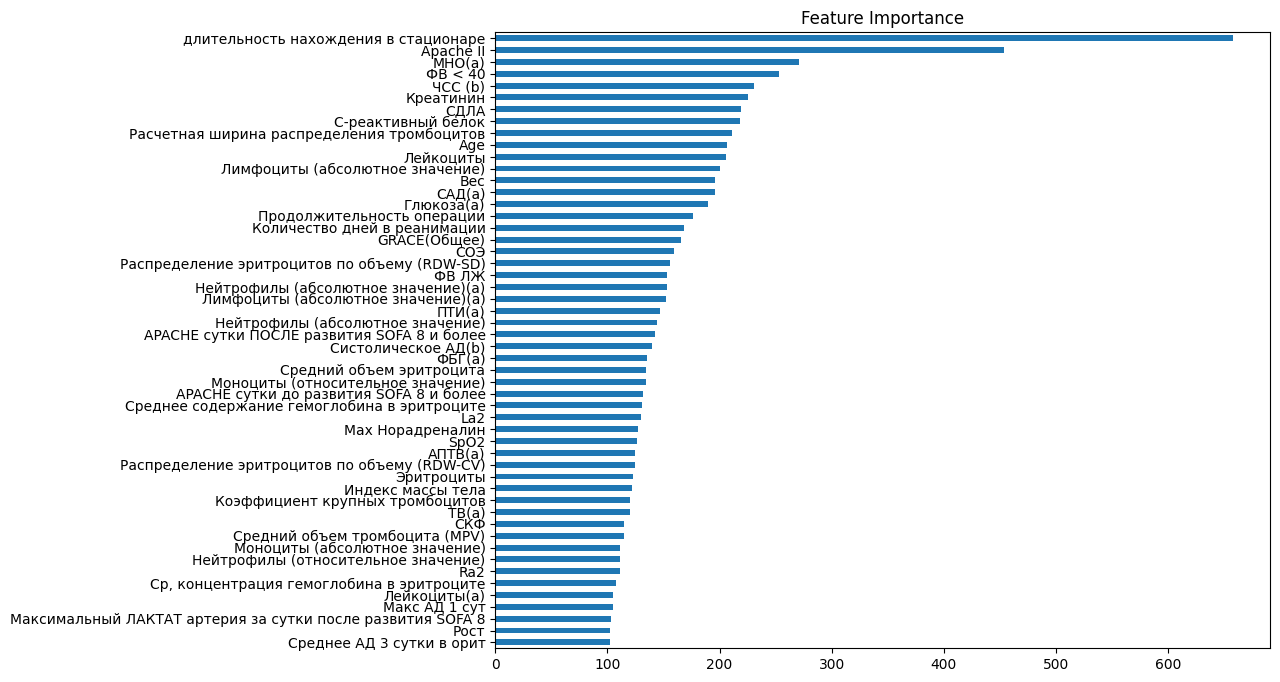

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
feature_importances = pd.Series(model.feature_importances_, index=x.columns)
feature_importances.sort_values()[250:].plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [152]:
text_data = pd.read_csv("anonymized_parsed_data_v8.csv")

In [140]:
text_data["patient_id"] = text_data["patient_id"].astype(object)

In [157]:
df2_subset = data[['Код пациента', 'Смерть']]
df2_subset.rename(columns={'Код пациента': 'patient_id', 'Смерть': 'label'}, inplace=True)

df2_subset["patient_id"] = df2_subset["patient_id"].astype(str)
text_data['patient_id'] = text_data['patient_id'].apply(lambda x: str(int(x)) if pd.notna(x) else None)

# Делаем merge по идентификатору
df1 = text_data.merge(df2_subset, on='patient_id', how='inner')

/tmp/ipykernel_170/1822087472.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_subset.rename(columns={'Код пациента': 'patient_id', 'Смерть': 'label'}, inplace=True)
/tmp/ipykernel_170/1822087472.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_subset["patient_id"] = df2_subset["patient_id"].astype(str)


In [164]:
df1

,patient_id,anonymized_text_data,label
0,10765,"Подождите, пожалуйста... Идет подготовка к выв...",Нет
1,5117,"Подождите, пожалуйста... Идет подготовка к выв...",Нет
2,17031,"Подождите, пожалуйста... Идет подготовка к выв...",Нет
3,269,"Подождите, пожалуйста... Идет подготовка к выв...",Нет
4,18250,"Подождите, пожалуйста... Идет подготовка к выв...",Нет
...,...,...,...
725,15706,"Подождите, пожалуйста... Идет подготовка к выв...",Нет
726,15228,"Подождите, пожалуйста... Идет подготовка к выв...",Нет
727,12513,"Подождите, пожалуйста... Идет подготовка к выв...",Нет
728,10622,"Подождите, пожалуйста... Идет подготовка к выв...",Нет


In [193]:
df1["label"].value_counts(normalize=True) * 100

label
0    95.479452
1     4.520548
Name: proportion, dtype: float64

In [183]:
df1["label"] = df1["label"].map({"Да": 1, "Нет": 0})

In [128]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [127]:
!pip install transformers datasets torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 221.4 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 1.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 1.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.1/75.1 kB 1.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 9.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.8/899.8 MB 3.2 MB/s eta 0:00:0000:01m00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 3.2 MB/s eta 0:00:0000:0100:02m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 7.9 MB/s eta 0:00:0000:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 8.7 MB/s eta 0:00:00:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 6.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━

In [129]:
print("hello world")

hello world


In [167]:
!pip install 'accelerate>=0.26.0'

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 814.1 kB/s eta 0:00:0000:0100:01


In [173]:
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
from torch.optim import AdamW

In [184]:
# === 1. Подготовка данных ===
model_name = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Модель загружена")

# Предположим, df1 уже есть с колонками "anonymized_text_data" и "label"
dataset = Dataset.from_pandas(df1)

print("Датасет получен")

def tokenize(batch):
    return tokenizer(batch["anonymized_text_data"], padding="max_length", truncation=True, max_length=256)

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.rename_column("label", "labels")
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print("Датасет преобразован")

train_test = dataset.train_test_split(test_size=0.2)
train_dataset = train_test["train"]
test_dataset = train_test["test"]

Модель загружена
Датасет получен


Map: 100%|██████████| 730/730 [00:01<00:00, 372.22 examples/s]

Датасет преобразован


In [185]:
def collate_fn(batch):
    return {
        "input_ids": torch.stack([item["input_ids"] for item in batch]),
        "attention_mask": torch.stack([item["attention_mask"] for item in batch]),
        "labels": torch.tensor([item["labels"] for item in batch]),
    }

In [196]:
import torch
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df1["label"]),
    y=df1["label"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

In [197]:
class_weights

tensor([ 0.5237, 11.0606])

In [198]:
from torch.nn import CrossEntropyLoss

loss_fn = CrossEntropyLoss(weight=class_weights.to(device))

In [199]:
# === 2. Настройка модели и оптимизатора ===
device = torch.device("cpu")  # явно CPU
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.to(device)

print("Модель на cpu")

optimizer = AdamW(model.parameters(), lr=5e-5)

# dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# === 3. DataLoaders ===
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=16, collate_fn=collate_fn)

print("Дата загружена")
# === 4. Тренировочный цикл ===
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = loss_fn(outputs.logits, labels)
        # loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}")

# === 5. Оценка на тесте ===
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=-1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

print(f"Accuracy on test set: {correct/total:.4f}")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Модель на cpu
Дата загружена
Epoch 1/10, Loss: 0.6600
Epoch 2/10, Loss: 0.6714
Epoch 3/10, Loss: 0.6296
Epoch 4/10, Loss: 0.6351
Epoch 5/10, Loss: 0.6253
Epoch 6/10, Loss: 0.6320
Epoch 7/10, Loss: 0.6272
Epoch 8/10, Loss: 0.5314
Epoch 9/10, Loss: 0.4010
Epoch 10/10, Loss: 0.2545
Accuracy on test set: 0.9521


In [200]:
from sklearn.metrics import classification_report

preds, labels = [], []
model.eval()

for batch in test_loader:
    outputs = model(
        input_ids=batch["input_ids"].to(device),
        attention_mask=batch["attention_mask"].to(device)
    )
    preds.extend(outputs.logits.argmax(dim=1).cpu().numpy())
    labels.extend(batch["labels"].numpy())

print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       139
           1       0.50      0.29      0.36         7

    accuracy                           0.95       146
   macro avg       0.73      0.64      0.67       146
weighted avg       0.94      0.95      0.95       146



In [191]:
mock = pd.read_csv("anonymized_parsed_data_analyzes.csv")

In [52]:
mock

NameError: name 'mock' is not defined

In [201]:
mock_history = pd.read_csv("anonymized_parsed_data_histories.csv")

In [204]:
mock_history["anonymized_text_data"][0]

'СОГЛАСИЕ на обработку персональных данных пациента Я, нижеподписавшийся (\nФ.И.О. полностью) [ФИО] зарегистрированный по адресу: край. Приморский, р-н. Уссурийский, с.Новоникольск, ул. Советская д.92 кв.9 проживающий по адресу: край. Приморский, р-н. Уссурийский, с. Новоникольск, [АДРЕС], документ , удостоверяющий личность: паспорт серия 05 03 № 670316 , выдан 03.07.2003 Орган, выдавший паспорт ОВД Уссурийска р-на ПК в соответствии с требованиями статьи 9 Федерального закона от 27.07.2006 № 152-ФЗ «О персональных данных», Федерального закона от 29.12.2006 №255-ФЗ «Об обязательном социальном страховании на случай временной нетрудоспособности и в связи с материнством», Федерального закона от 29.11.2010 №326-ФЗ»«Об обязательном медицинском страховании в Российской Федерации», даю свое согласие на обработку Государственным бюджетным учреждением здравоохранения «Приморская краевая клиническая больница №1» (ИНН[ТЕЛЕФОН] ОГРН[ТЕЛЕФОН]43: 5, местонахождение: г. Владивосток ул. Алеутская, 57) 